# **1. Data Loading**

**Get the data into a clean, memory-manageable, well-understood state so Days 2+ (EDA deep-dive, disparity analysis, modeling) can move fast. No modeling or deep disparity work today — this is foundation day.**

In [1]:
import pyarrow.parquet as pq
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Path after mounting Drive, e.g. '/content/drive/MyDrive/HMDA_Data/hmda_2024.parquet'
file_path = "../data/raw/hmda_2024.parquet"

# 1. Metadata only — instant, doesn't load data into memory
pf = pq.ParquetFile(file_path)
print("Number of records:", pf.metadata.num_rows)
print("Number of columns:", pf.metadata.num_columns)
print("\nColumn names and dtypes:")
for field in pf.schema_arrow:
    print(f"  {field.name}: {field.type}")

# 2. Peek at first few rows (only reads a small slice, not the full file)
# df_sample = pf.read_row_group(0).to_pandas().head(10)
# print("\nSample rows:")
# display(df_sample)

# 3. Quick memory/size sanity check
print(f"\nFile size on disk: {round(pf.metadata.serialized_size / (1024**2), 2)} MB (metadata only)")

Number of records: 12229298
Number of columns: 99

Column names and dtypes:
  activity_year: string
  lei: string
  derived_msa_md: string
  state_code: string
  county_code: string
  census_tract: string
  conforming_loan_limit: string
  derived_loan_product_type: string
  derived_dwelling_category: string
  derived_ethnicity: string
  derived_race: string
  derived_sex: string
  action_taken: string
  purchaser_type: string
  preapproval: string
  loan_type: string
  loan_purpose: string
  lien_status: string
  reverse_mortgage: string
  open_end_line_of_credit: string
  business_or_commercial_purpose: string
  loan_amount: string
  loan_to_value_ratio: string
  interest_rate: string
  rate_spread: string
  hoepa_status: string
  total_loan_costs: string
  total_points_and_fees: string
  origination_charges: string
  discount_points: string
  lender_credits: string
  loan_term: string
  prepayment_penalty_term: string
  intro_rate_period: string
  negative_amortization: string
  inte

### **Step 1 — Column Triage & Data Dictionary**

Based on the official HMDA LAR field documentation. We group all 99 columns by role so we only load/type what we need for the 3 project goals (EDA, fair-lending analysis, modeling).

In [3]:
# --- Leakage-aware column groups (per HMDA LAR data dictionary + domain expertise) ---
#
# Three disjoint roles:
#   1) MODEL_*   -> legitimate pre-decision underwriting features. SAFE to feed a model.
#   2) FAIR_*    -> protected / demographic characteristics. KEPT for disparity audit
#                   but EXCLUDED from model inputs (ethically + legally required).
#   3) LEAKAGE_* -> post-decision / outcome-derived fields. EXCLUDED from modeling;
#                   kept only in the analysis parquet for EDA context.
#
# NOTE: ID_GEO_COLS and TARGET_COL are tracked separately and are DELIBERATELY
# NOT folded into MODEL_COLUMNS (see fix below) - see rationale in Step 6.

# Identifiers / geography - grouping keys, NOT model features by default
ID_GEO_COLS = ["activity_year", "lei", "derived_msa_md", "state_code", "county_code", "census_tract"]

# --- MODEL_NUMERIC: numeric underwriting features known at application time ---
MODEL_NUMERIC_COLS = [
    "loan_amount", "loan_to_value_ratio", "property_value", "income",
    "debt_to_income_ratio", "loan_term", "conforming_loan_limit",
    "total_units", "prepayment_penalty_term", "intro_rate_period",
    # Tract context (NUMERIC) - potential RACE PROXIES, flag for fair-lending review
    "tract_population", "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income", "tract_to_msa_income_percentage",
    "tract_owner_occupied_units", "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units",
]

# --- MODEL_CATEGORICAL: categorical underwriting features known at application time ---
MODEL_CATEGORICAL_COLS = [
    "loan_type", "loan_purpose", "lien_status", "occupancy_type",
    "construction_method", "derived_dwelling_category",
    "applicant_credit_score_type", "co_applicant_credit_score_type",
    "submission_of_application", "reverse_mortgage",
    "open_end_line_of_credit", "business_or_commercial_purpose", "preapproval",
    # Risky-feature flags (product terms known pre-decision, not leakage)
    "negative_amortization", "interest_only_payment", "balloon_payment",
]

# --- FAIR_LENDING: protected characteristics (AUDIT ONLY, never model inputs) ---
FAIR_LENDING_COLS = [
    "derived_ethnicity", "derived_race", "derived_sex",
    "applicant_age", "co_applicant_age",
    "applicant_age_above_62", "co_applicant_age_above_62",
]

# Outcome variable
TARGET_COL = "action_taken"

# --- LEAKAGE (post-decision): kept for analysis parquet, never for modeling ---
LEAKAGE_NUMERIC_COLS = [
    "interest_rate", "rate_spread", "total_loan_costs", "total_points_and_fees",
    "origination_charges", "discount_points", "lender_credits",
]
LEAKAGE_CATEGORICAL_COLS = [
    "hoepa_status", "purchaser_type",
    "denial_reason_1", "denial_reason_2", "denial_reason_3", "denial_reason_4",
]

# Columns dropped entirely for Day 1 (raw race/ethnicity/sex slots, *_observed flags,
# AUS systems, manufactured-home detail, multi-applicant slots). Revisit later if needed.
DROPPED_FOR_NOW = [
    "applicant_ethnicity_1", "applicant_ethnicity_2", "applicant_ethnicity_3", "applicant_ethnicity_4", "applicant_ethnicity_5",
    "co_applicant_ethnicity_1", "co_applicant_ethnicity_2", "co_applicant_ethnicity_3",
    "co_applicant_ethnicity_4", "co_applicant_ethnicity_5",
    "applicant_ethnicity_observed", "co_applicant_ethnicity_observed",
    "applicant_race_1", "applicant_race_2", "applicant_race_3", "applicant_race_4", "applicant_race_5",
    "co_applicant_race_1", "co_applicant_race_2", "co_applicant_race_3", "co_applicant_race_4", "co_applicant_race_5",
    "applicant_race_observed", "co_applicant_race_observed",
    "applicant_sex", "co_applicant_sex", "applicant_sex_observed", "co_applicant_sex_observed",
    "aus_1", "aus_2", "aus_3", "aus_4", "aus_5",
    "other_nonamortizing_features", "manufactured_home_secured_property_type",
    "manufactured_home_land_property_interest", "multifamily_affordable_units",
    "initially_payable_to_institution", "derived_loan_product_type",
]

# What we actually load today
KEEP_COLUMNS = (
    ID_GEO_COLS + MODEL_NUMERIC_COLS + MODEL_CATEGORICAL_COLS
    + FAIR_LENDING_COLS + [TARGET_COL]
    + LEAKAGE_NUMERIC_COLS + LEAKAGE_CATEGORICAL_COLS
)
KEEP_COLUMNS = list(dict.fromkeys(KEEP_COLUMNS))  # de-dupe, preserve order

# --- FIX vs. earlier draft: MODEL_COLUMNS must contain ONLY feature columns. ---
# The previous version of this cell did:
#     MODEL_COLUMNS = ID_GEO_COLS + MODEL_NUMERIC_COLS + MODEL_CATEGORICAL_COLS + [TARGET_COL]
# which put the RAW TARGET (action_taken) inside the "safe to model" column list,
# and folded in high-cardinality / non-predictive IDs (lei, census_tract). Both are bugs:
#   - action_taken in the feature set = the model can trivially "predict" approved,
#     since approved is literally derived from action_taken (perfect leakage).
#   - census_tract (~74k unique values) is a raw identifier, not a usable numeric/
#     categorical feature, and is a well-known proxy for race (redlining-adjacent) -
#     same family of concern as tract_minority_population_percent, but worse because
#     it's an ID, not a rate. lei is just an institution ID with no predictive meaning.
# FIXED: MODEL_COLUMNS = feature columns ONLY. Geography is a deliberate, separate
# decision for Day 2+ (e.g. state_code as a coarse regional effect), not a default.
MODEL_COLUMNS = MODEL_NUMERIC_COLS + MODEL_CATEGORICAL_COLS

# Optional, NOT included by default - a coarser, lower-cardinality geographic
# feature some teams choose to add deliberately later (state, not tract/county/lei).
GEO_MODEL_CANDIDATE_COLS = ["state_code"]

print(f"Keeping {len(KEEP_COLUMNS)} of 99 columns for Day 1")
print(f"  - model-safe features       : {len(MODEL_COLUMNS)}")
print(f"  - fair-lending (audit only) : {len(FAIR_LENDING_COLS)}")
print(f"  - leakage (excluded)        : {len(LEAKAGE_NUMERIC_COLS) + len(LEAKAGE_CATEGORICAL_COLS)}")
print(f"  - id/geo (excluded from model by default): {len(ID_GEO_COLS)}")
print(f"Dropped-for-now: {len(DROPPED_FOR_NOW)} columns (still on disk, can reload later)")


Keeping 60 of 99 columns for Day 1
  - model-safe features       : 33
  - fair-lending (audit only) : 7
  - leakage (excluded)        : 13
  - id/geo (excluded from model by default): 6
Dropped-for-now: 39 columns (still on disk, can reload later)


### **Step 2 — Efficient, Typed Load**

Read only `KEEP_COLUMNS` (Parquet is columnar, so this is fast even on 12.2M rows), then cast each column to the right dtype instead of leaving everything as `string`.

In [4]:
# Read only the columns we decided to keep
df = pd.read_parquet(file_path, columns=KEEP_COLUMNS, engine="pyarrow")

print(f"Loaded shape: {df.shape}")
print(f"Memory usage (raw, all-string): {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")


Loaded shape: (12229298, 60)
Memory usage (raw, all-string): 8.62 GB


In [5]:
# --- Human-readable label maps for coded fields (from official HMDA docs) ---

ACTION_TAKEN_LABELS = {
    "1": "Loan originated",
    "2": "Application approved but not accepted",
    "3": "Application denied",
    "4": "Application withdrawn by applicant",
    "5": "File closed for incompleteness",
    "6": "Purchased loan",
    "7": "Preapproval request denied",
    "8": "Preapproval request approved but not accepted",
}

DENIAL_REASON_LABELS = {
    "1": "Debt-to-income ratio",
    "2": "Employment history",
    "3": "Credit history",
    "4": "Collateral",
    "5": "Insufficient cash (downpayment, closing costs)",
    "6": "Unverifiable information",
    "7": "Credit application incomplete",
    "8": "Mortgage insurance denied",
    "9": "Other",
    "10": "Not applicable",
}

# Sentinel / placeholder codes that mean "missing" or "exempt" rather than a
# real value. These show up across many numeric-looking fields in HMDA.
NUMERIC_SENTINELS = ["1111", "9999", "8888", "Exempt", "NA", ""]


In [6]:
# --- Cast numeric columns (model numerics + tract numerics + leakage numerics) ---
numeric_cols_present = [c for c in (MODEL_NUMERIC_COLS + LEAKAGE_NUMERIC_COLS) if c in df.columns]

for col in numeric_cols_present:
    s = df[col].replace(NUMERIC_SENTINELS, np.nan)
    df[col] = pd.to_numeric(s, errors="coerce").astype("float32")

# --- Cast categorical columns (dtype = category, saves a lot of memory on 12M rows) ---
# Model categoricals + fair-lending + target + leakage categoricals + id/geo
categorical_cols_present = [
    c for c in (
        ID_GEO_COLS + MODEL_CATEGORICAL_COLS + FAIR_LENDING_COLS
        + [TARGET_COL] + LEAKAGE_CATEGORICAL_COLS
    ) if c in df.columns
]

for col in categorical_cols_present:
    df[col] = df[col].astype("category")

# --- Apply human-readable labels for the two most-used coded fields ---
df["action_taken_label"] = df["action_taken"].map(ACTION_TAKEN_LABELS).astype("category")
for col in ["denial_reason_1", "denial_reason_2", "denial_reason_3", "denial_reason_4"]:
    if col in df.columns:
        df[col + "_label"] = df[col].map(DENIAL_REASON_LABELS).astype("category")

print(f"Memory usage (typed): {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
df.dtypes


Memory usage (typed): 1.75 GB


activity_year            category
lei                      category
derived_msa_md           category
state_code               category
county_code              category
                           ...   
action_taken_label       category
denial_reason_1_label    category
denial_reason_2_label    category
denial_reason_3_label    category
denial_reason_4_label    category
Length: 65, dtype: object

### **Step 3 — Understand the Target (`action_taken`)**

Decide the analysis population before doing any disparity work or modeling.

In [7]:
action_counts = df["action_taken_label"].value_counts()
action_pct = (action_counts / len(df) * 100).round(2)

action_summary = pd.DataFrame({"count": action_counts, "pct": action_pct})
print(action_summary)


                                                 count    pct
action_taken_label                                           
Loan originated                                6176052  50.50
Application denied                             2099966  17.17
Application withdrawn by applicant             1536699  12.57
Purchased loan                                 1273313  10.41
File closed for incompleteness                  581629   4.76
Application approved but not accepted           360560   2.95
Preapproval request approved but not accepted   153652   1.26
Preapproval request denied                       47427   0.39


In [8]:
# Decision: keep only records representing an actual lender decision -
# Originated (1) or Denied (3). Withdrawn/incomplete/purchased/preapproval-only
# records don't reflect a completed approve/deny decision, so we exclude them
# from the modeling + disparity population (documented here for Day 2+).

DECISION_CODES = ["1", "3"]  # originated, denied
df_decisions = df[df["action_taken"].isin(DECISION_CODES)].copy()
df_decisions["approved"] = (df_decisions["action_taken"] == "1").astype("int8")

print(f"Full dataset: {len(df):,} rows")
print(f"Decision subset (originated + denied): {len(df_decisions):,} rows "
      f"({len(df_decisions) / len(df) * 100:.1f}% of full dataset)")
approved_rate = df_decisions["approved"].mean() * 100
print(f"Approval rate in decision subset: {approved_rate:.2f}%")


Full dataset: 12,229,298 rows
Decision subset (originated + denied): 8,276,018 rows (67.7% of full dataset)
Approval rate in decision subset: 74.63%


### **Step 4 — Data Quality Audit**

In [9]:
# Missingness across the columns we kept
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_report = missing_pct[missing_pct > 0].to_frame("pct_missing")
print(f"Columns with any missing values: {len(missing_report)} / {df.shape[1]}")
missing_report.head(20)


Columns with any missing values: 31 / 65


,pct_missing
conforming_loan_limit,100.00
denial_reason_4_label,99.87
denial_reason_4,99.87
denial_reason_3_label,99.28
denial_reason_3,99.28
total_points_and_fees,99.13
prepayment_penalty_term,96.84
denial_reason_2_label,96.16
denial_reason_2,96.16
lender_credits,85.51


In [10]:
# Exact duplicate rows
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count:,} ({dup_count / len(df) * 100:.4f}%)")

# Sanity-check numeric ranges on the decision subset (originated + denied only)
numeric_summary = df_decisions[numeric_cols_present].describe().T
numeric_summary["pct_missing"] = df_decisions[numeric_cols_present].isna().mean().mul(100).round(2)
numeric_summary


Exact duplicate rows: 29,475 (0.2410%)


,count,mean,std,min,25%,50%,75%,max,pct_missing
loan_amount,8276018.0,299442.156250,1.974081e+06,5000.000,95000.000000,205000.000000,355000.000000,2.650005e+09,0.00
loan_to_value_ratio,7438582.0,2741.126953,4.360819e+06,0.001,60.000000,78.760002,92.032997,1.093680e+10,10.12
property_value,7743138.0,559093.250000,4.384118e+06,5000.000,255000.000000,385000.000000,595000.000000,2.147484e+09,6.44
income,7768743.0,188.822281,3.956404e+04,-155317.000,67.000000,104.000000,164.000000,1.000000e+08,6.13
debt_to_income_ratio,3561347.0,42.862820,3.998809e+00,36.000,40.000000,43.000000,46.000000,4.900000e+01,56.97
loan_term,7877414.0,319.147888,8.420266e+01,1.000,300.000000,360.000000,360.000000,3.292000e+03,4.82
conforming_loan_limit,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.00
total_units,8239488.0,1.037109,2.514546e-01,1.000,1.000000,1.000000,1.000000,4.000000e+00,0.44
prepayment_penalty_term,313843.0,31.551374,1.020677e+01,0.000,24.000000,36.000000,36.000000,3.600000e+02,96.21
intro_rate_period,1820702.0,16.822281,9.506544e+01,1.000,1.000000,1.000000,12.000000,1.201000e+05,78.00


In [11]:
# Cardinality / "Not Available" checks on the demographic fields used for
# fair-lending analysis - important to know how much of the data we can
# actually use for that purpose.
for col in ["derived_race", "derived_ethnicity", "derived_sex"]:
    print(f"\n--- {col} ---")
    print(df_decisions[col].value_counts(normalize=True).mul(100).round(2))



--- derived_race ---
derived_race
White                                        64.22
Race Not Available                           17.46
Black or African American                     8.81
Asian                                         6.06
Joint                                         2.20
American Indian or Alaska Native              0.73
2 or more minority races                      0.25
Native Hawaiian or Other Pacific Islander     0.24
Free Form Text Only                           0.03
Name: proportion, dtype: float64

--- derived_ethnicity ---
derived_ethnicity
Not Hispanic or Latino     69.08
Ethnicity Not Available    16.15
Hispanic or Latino         12.14
Joint                       2.60
Free Form Text Only         0.04
Name: proportion, dtype: float64

--- derived_sex ---
derived_sex
Joint                34.91
Male                 33.69
Female               22.53
Sex Not Available     8.87
Name: proportion, dtype: float64


### **Step 5 — Light Initial EDA**

Descriptive only — save the race/sex-vs-outcome crosstabs and statistical testing for Day 2.

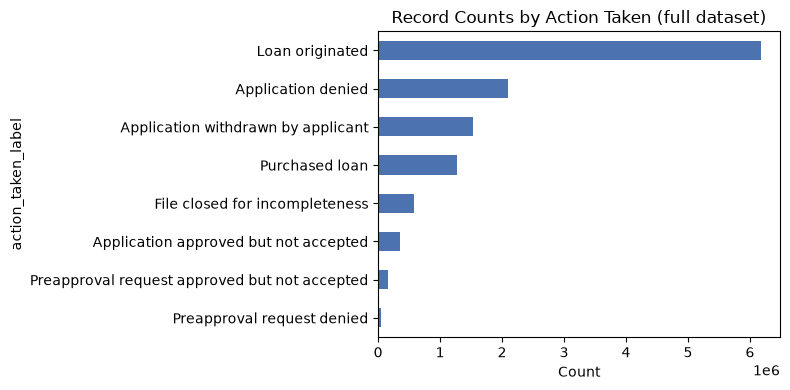

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
action_counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Record Counts by Action Taken (full dataset)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


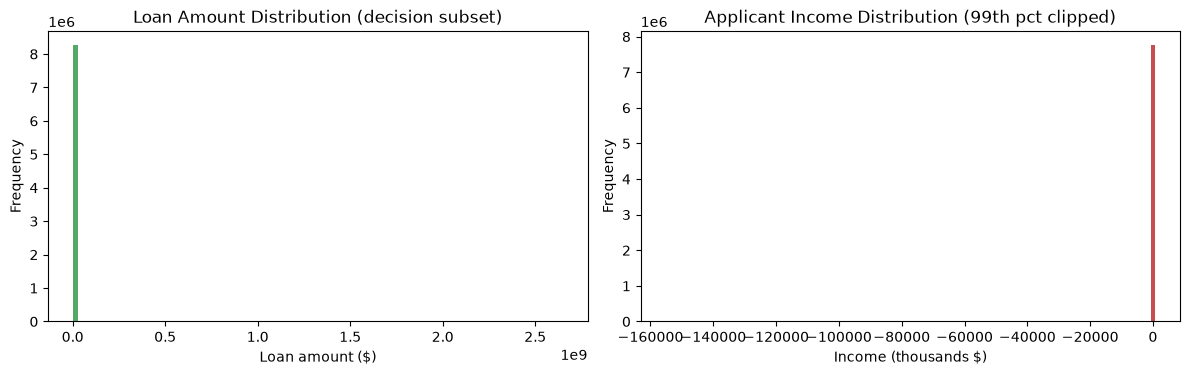

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_decisions["loan_amount"].dropna().plot(kind="hist", bins=100, ax=axes[0], color="#55A868")
axes[0].set_title("Loan Amount Distribution (decision subset)")
axes[0].set_xlabel("Loan amount ($)")

df_decisions["income"].dropna().clip(upper=df_decisions["income"].quantile(0.99)).plot(
    kind="hist", bins=100, ax=axes[1], color="#C44E52"
)
axes[1].set_title("Applicant Income Distribution (99th pct clipped)")
axes[1].set_xlabel("Income (thousands $)")

plt.tight_layout()
plt.show()


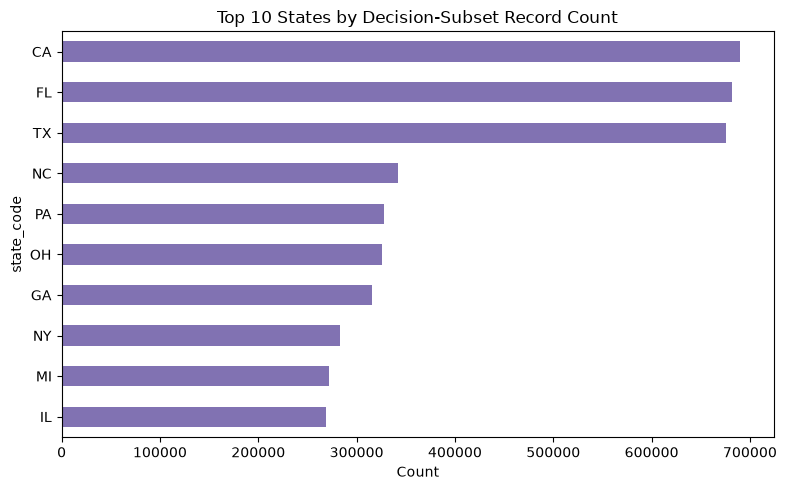

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
df_decisions["state_code"].value_counts().head(10).sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Top 10 States by Decision-Subset Record Count")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


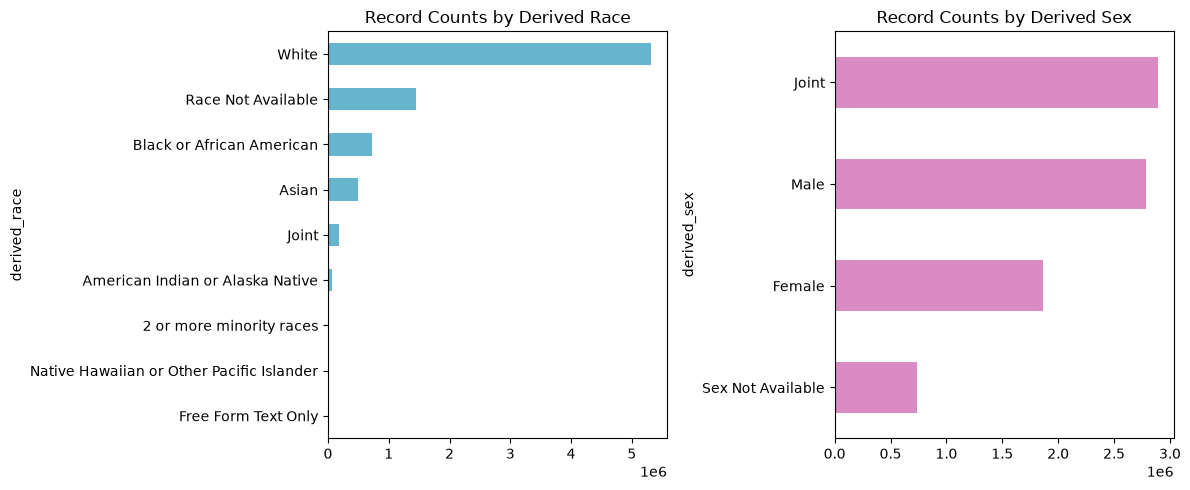

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_decisions["derived_race"].value_counts().sort_values().plot(kind="barh", ax=axes[0], color="#64B5CD")
axes[0].set_title("Record Counts by Derived Race")

df_decisions["derived_sex"].value_counts().sort_values().plot(kind="barh", ax=axes[1], color="#DA8BC3")
axes[1].set_title("Record Counts by Derived Sex")

plt.tight_layout()
plt.show()


**Observations (fill in after running):**\n- \n- \n- \n\n(Keep this descriptive only — no approval-rate-by-race comparisons yet, that's Day 2.)

### **Step 6 — Save Outputs for next file**

In [16]:
import os

os.makedirs("../data/processed", exist_ok=True)

# --- Modeling-only extract: features ONLY. No target, no protected characteristics,
# no leakage columns, no raw geo IDs. This is the file Day 4+ (feature engineering /
# training) should load, and it should have exactly one label column: "approved".
df_model = df[MODEL_COLUMNS].copy()
df_model_decisions = df_decisions[MODEL_COLUMNS].copy()

df_model["approved"] = (df["action_taken"] == "1").astype("int8")
df_model_decisions["approved"] = df_decisions["approved"]

# Sanity check: the raw target must NOT be sitting inside the model feature set
assert TARGET_COL not in df_model.columns, "Target leaked into model columns!"
assert TARGET_COL not in df_model_decisions.columns, "Target leaked into model columns!"

# Full analysis dataset (all kept cols, incl. fair-lending + leakage) for EDA
df.to_parquet("../data/processed/hmda_2024_typed.parquet", index=False)
df_decisions.to_parquet("../data/processed/hmda_2024_decisions.parquet", index=False)

# Clean modeling datasets (leakage-free, fair-lending excluded, target excluded)
df_model.to_parquet("../data/processed/hmda_2024_model.parquet", index=False)
df_model_decisions.to_parquet("../data/processed/hmda_2024_model_decisions.parquet", index=False)

# Column dictionary with ROLE + LEAKAGE flag, for reference in later notebooks
def _role(col):
    if col in MODEL_NUMERIC_COLS: return "model_numeric"
    if col in MODEL_CATEGORICAL_COLS: return "model_categorical"
    if col in FAIR_LENDING_COLS: return "fair_lending_audit_only"
    if col in LEAKAGE_NUMERIC_COLS or col in LEAKAGE_CATEGORICAL_COLS: return "leakage_excluded"
    if col == TARGET_COL: return "target"
    return "id_geo_excluded_by_default"

col_dict = pd.DataFrame({
    "column": KEEP_COLUMNS,
    "role": [_role(c) for c in KEEP_COLUMNS],
    "use_in_model": ["YES" if _role(c).startswith("model") else "NO" for c in KEEP_COLUMNS],
})
col_dict.to_csv("../data/processed/1_column_dictionary.csv", index=False)

print("Saved:")
print("  ../data/processed/hmda_2024_typed.parquet              ", df.shape)
print("  ../data/processed/hmda_2024_decisions.parquet          ", df_decisions.shape)
print("  ../data/processed/hmda_2024_model.parquet (LEAKAGE-FREE)", df_model.shape)
print("  ../data/processed/hmda_2024_model_decisions.parquet    ", df_model_decisions.shape)
print("  ../data/processed/1_column_dictionary.csv               ", col_dict.shape)
print()
print(f"MODEL_COLUMNS ({len(MODEL_COLUMNS)}) — no target, no fair-lending cols, no leakage cols, no raw geo IDs:")
print(MODEL_COLUMNS)


Saved:
  ../data/processed/hmda_2024_typed.parquet               (12229298, 65)
  ../data/processed/hmda_2024_decisions.parquet           (8276018, 66)
  ../data/processed/hmda_2024_model.parquet (LEAKAGE-FREE) (12229298, 34)
  ../data/processed/hmda_2024_model_decisions.parquet     (8276018, 34)
  ../data/processed/1_column_dictionary.csv                (60, 3)

MODEL_COLUMNS (33) — no target, no fair-lending cols, no leakage cols, no raw geo IDs:
['loan_amount', 'loan_to_value_ratio', 'property_value', 'income', 'debt_to_income_ratio', 'loan_term', 'conforming_loan_limit', 'total_units', 'prepayment_penalty_term', 'intro_rate_period', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units', 'loan_type', 'loan_purpose', 'lien_status', 'occupancy_type', 'construction_method', 'derived_dwelling_category', 'applicant_c

## **1_data_load.ipynb Summary**

- **Full dataset:** 12,229,298 rows x 99 cols (raw) -> loaded 60 kept cols, typed to ~1.6 GB.
- **Decision subset (originated + denied):** 8,276,018 rows (67.7% of full); approval rate 74.63%.
- **Leakage audit (round 1):** post-decision fields (`interest_rate`, `rate_spread`, `denial_reason_*`, loan-cost fields, `hoepa_status`, `purchaser_type`) are separated into a `leakage_excluded` role and never written to the modeling parquet.
- **Leakage audit (round 2 - caught while reviewing the fix itself):** an earlier draft of `MODEL_COLUMNS` accidentally included the raw target (`action_taken`) and raw geo IDs (`lei`, `census_tract`, `county_code`, `derived_msa_md`) in the "safe to model" column list. Fixed: `MODEL_COLUMNS` is now feature-only (`MODEL_NUMERIC_COLS + MODEL_CATEGORICAL_COLS`), with an `assert` guarding against the target ever leaking back in. Geography is left out by default and flagged as a deliberate Day 2+ decision (`GEO_MODEL_CANDIDATE_COLS`), same as the tract-proxy issue below.
- **Fair-lending audit:** `derived_race/ethnicity/sex` + `applicant_age*` kept for disparity analysis but flagged `fair_lending_audit_only` and excluded from the modeling parquet.
- **Open judgment call:** `tract_minority_population_percent` (and other tract_* fields) are in `MODEL_NUMERIC_COLS` - not leakage, but a known race proxy. Revisit before final model training: keep for signal vs. drop for a cleaner fair-lending posture.
- **Saved artifacts:**
  - `hmda_2024_model.parquet` / `hmda_2024_model_decisions.parquet` — leakage-free, fair-lending-excluded, target-excluded modeling inputs (what Day 4+ trains on). Only label column is `approved`.
  - `hmda_2024_typed.parquet` / `hmda_2024_decisions.parquet` — full analysis frame (incl. fair-lending + leakage) for EDA.
  - `1_column_dictionary.csv` — every kept column tagged with `role` + `use_in_model`.
- **Key open questions for Day 2:**
  - How does approval rate vary by `derived_race` / `derived_sex`, controlling for `income`, `loan_amount`, `debt_to_income_ratio`?
  - Do `tract_minority_population_percent` and other tract fields act as proxies for race (redlining-adjacent risk)?
  - Which denial reasons are most common, and do they differ by demographic group? (Use the analysis frame, not the model frame, for this - `denial_reason_*` is leakage-excluded from modeling but fine for descriptive EDA.)
  - `debt_to_income_ratio` is 33% missing and `loan_to_value_ratio` 35% missing — what imputation strategy for Day 4?
  - Should `state_code` (from `GEO_MODEL_CANDIDATE_COLS`) be added back as a coarse regional feature, or left out entirely given the tract-proxy concern?

### End-of-Day-1 Checklist
- [x] Raw data loaded with proper dtypes (not all-string)
- [x] Reduced + typed datasets saved to Parquet
- [x] Leakage-aware column triage (model / fair-lending / leakage roles)
- [x] Target-leak bug in `MODEL_COLUMNS` found and fixed, with an assertion guard
- [x] Column dictionary documented with role + use_in_model flag
- [x] `action_taken` understood, decision-subset + binary target created
- [x] Missingness / sentinel-value audit done
- [x] Duplicate check done (29,384 exact dups, 0.24%)
- [x] Basic EDA charts produced
